In [1]:
!pip install optuna
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import os
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from collections import Counter
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from transformers import DistilBertConfig, DistilBertForSequenceClassification
from transformers.optimization import Adafactor
from sklearn.metrics import f1_score
import numpy as np
import random
import optuna
from optuna.samplers import TPESampler
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


def set_seed(seed_value=42):
    os.environ['PYTHONHASHSEED']=str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.use_deterministic_algorithms(True, warn_only=True)



set_seed(42)
dataset = load_dataset("ailsntua/QEvasion")
print("Dataset structure:")
print(dataset)
print("-" * 50)

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
train_df.head()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df['clarity_label']
)

print(f"Training Set new size: {len(train_df)}")
print(f"Validation Set size: {len(val_df)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})
--------------------------------------------------
Training Set new size: 2758
Validation Set size: 690


In [2]:
train_duplicates = train_df.duplicated(subset=['question', 'interview_answer']).sum()
if train_duplicates > 0:
    train_df = train_df.drop_duplicates(subset=['question', 'interview_answer'])
    print(f"Dropped {train_duplicates} duplicates from Training Set.")

val_duplicates = val_df.duplicated(subset=['question', 'interview_answer']).sum()
if val_duplicates > 0:
    val_df = val_df.drop_duplicates(subset=['question', 'interview_answer'])
    print(f"Dropped {val_duplicates} duplicates from Validation Set.")

val_size_before = len(val_df)
val_df = val_df[~val_df.set_index(['question', 'interview_answer']).index.isin(
    train_df.set_index(['question', 'interview_answer']).index
)]
leakage_count = val_size_before - len(val_df)
print(f"- {leakage_count} instances dropped from Validation set (already existed in Training set).")
print(f"- Training Set final size: {len(train_df)}")
print(f"- Validation Set final size: {len(val_df)}")

Dropped 34 duplicates from Training Set.
Dropped 3 duplicates from Validation Set.
- 21 instances dropped from Validation set (already existed in Training set).
- Training Set final size: 2724
- Validation Set final size: 666


In [3]:
print("Unique clarity labels:", train_df['clarity_label'].unique())

label_mapping = {"Clear Reply": 0, "Ambivalent": 1, "Clear Non-Reply": 2}

train_df['label'] = train_df['clarity_label'].map(label_mapping)
val_df['label'] = val_df['clarity_label'].map(label_mapping)

print(f"NaN in Train: {train_df['label'].isnull().sum()}")
print(f"NaN in Val: {val_df['label'].isnull().sum()}")

print("\n" + "="*50)
print("SAMPLE QUESTION FROM TRAINING SET:")
print(train_df['interview_question'].iloc[0])
print("-" * 50)
print("SAMPLE ANSWER:")
print(train_df['interview_answer'].iloc[0])
print("-" * 50)
print("LABEL (Word):", train_df['clarity_label'].iloc[0])
print("LABEL (Number):", train_df['label'].iloc[0])
print("="*50)

Unique clarity labels: ['Clear Non-Reply' 'Clear Reply' 'Ambivalent']
NaN in Train: 0
NaN in Val: 0

SAMPLE QUESTION FROM TRAINING SET:
Q. Mr. President—[inaudible]—Valentinovna, Sputnik News Agency. Have you discussed the issue of possible inspections to North Korea's nuclear sites during your negotiations?
--------------------------------------------------
SAMPLE ANSWER:
You're going to have to speak a little louder. And where are you from? Where are you from?
--------------------------------------------------
LABEL (Word): Clear Non-Reply
LABEL (Number): 2


Class Distribution:
clarity_label
Ambivalent         1607
Clear Reply         836
Clear Non-Reply     281
Name: count, dtype: int64

Percentages:
clarity_label
Ambivalent         58.99%
Clear Reply        30.69%
Clear Non-Reply    10.32%
Name: count, dtype: object


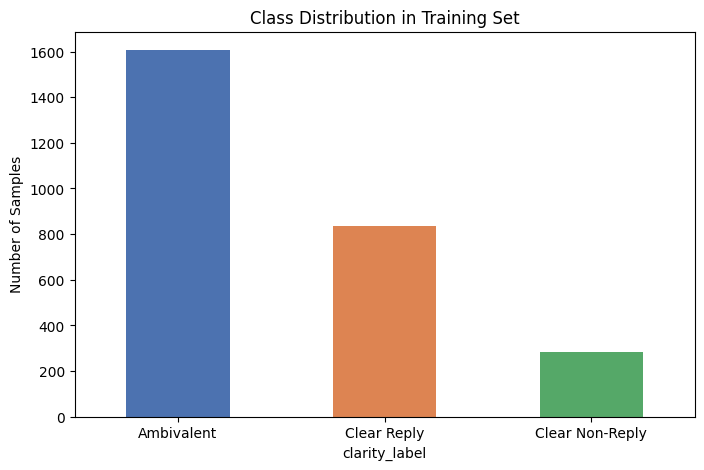

In [4]:
print("Class Distribution:")
class_counts = train_df['clarity_label'].value_counts()
print(class_counts)

percentages = (class_counts / len(train_df)) * 100
print("\nPercentages:")
print(percentages.round(2).astype(str) + "%")

class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], figsize=(8,5))
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [5]:
label_mapping = {"Clear Reply": 0, "Ambivalent": 1, "Clear Non-Reply": 2}

for df in [train_df, val_df]:
    df['label'] = df['clarity_label'].map(label_mapping)
    df.dropna(subset=['question', 'interview_answer', 'label'], inplace=True)
    df.reset_index(drop=True, inplace=True)

test_df['label'] = test_df['clarity_label'].map(label_mapping)
test_df['question'] = test_df['question'].fillna("")
test_df['interview_answer'] = test_df['interview_answer'].fillna("")

print("Searching for Missing Values in Training:")
print(train_df[['question', 'interview_answer', 'label']].isnull().sum())

print("-" * 30)
print(f"Final Train size: {len(train_df)}")
print(f"Final Val size: {len(val_df)}")
print(f"Final Test size: {len(test_df)}")

Searching for Missing Values in Training:
question            0
interview_answer    0
label               0
dtype: int64
------------------------------
Final Train size: 2724
Final Val size: 666
Final Test size: 308


In [6]:
class ClarityDataset(Dataset):

    def __init__(self, questions, answers, labels, tokenizer, max_len):
        self.questions = questions
        self.answers = answers
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, item):
        question = str(self.questions[item])
        answer = str(self.answers[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            question,
            answer,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
MAX_LEN = 512
BATCH_SIZE = 16

train_dataset = ClarityDataset(
    questions=train_df.question.to_numpy(),
    answers=train_df.interview_answer.to_numpy(),
    labels=train_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

val_dataset = ClarityDataset(
    questions=val_df.question.to_numpy(),
    answers=val_df.interview_answer.to_numpy(),
    labels=val_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_dataset = ClarityDataset(
    questions=test_df.question.to_numpy(),
    answers=test_df.interview_answer.to_numpy(),
    labels=test_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DataLoaders ready. Train batches: 171, Val batches: 42, Test batches: 20


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model_name = "distilbert-base-uncased"
set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3 # 0: Clear Reply, 1: Ambivalent, 2: Clear Non-Reply
)
model.to(device)

labels = train_df['label'].tolist()
counts = Counter(labels)
total = sum(counts.values())
weights = [total / counts[i] for i in range(3)]
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print("The model has loaded.")
print("Implemented Class Weights:")
print(f"- Clear Reply (0): {weights[0]:.2f}")
print(f"- Ambivalent (1): {weights[1]:.2f}")
print(f"- Clear Non-Reply (2): {weights[2]:.2f}")

Using: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The model has loaded.
Implemented Class Weights:
- Clear Reply (0): 3.26
- Ambivalent (1): 1.70
- Clear Non-Reply (2): 9.69


Σε αυτό το βήμα, δημιουργούμε έναν βασικό βρόχο εκπαίδευσης (training loop) για να τρέξουμε το DistilBERT με τις προεπιλεγμένες παραμέτρους (LR=2e-5, Batch=16) και να αποκτήσουμε ένα αρχικό F1-Score ως σημείο αναφοράς.

In [8]:
optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3
best_f1 = 0.0
best_epoch = 0

print(f"Starting Training on {device}...\n")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for batch in train_loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    current_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean()

    print(f"\nEnd of Epoch {epoch+1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%} | Val F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"New Best Model saved with Macro F1: {best_f1:.4f}")

    print("-" * 50)

print(f"\nFine-tuning completed.")
print(f"The best model was found at Epoch {best_epoch} with Validation Macro F1 Score: {best_f1:.2%}")


Starting Training on cuda...



Epoch 1/3 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1/3 [Train]: 100%|██████████| 171/171 [02:12<00:00,  1.29it/s, loss=0.562]



End of Epoch 1:
Train Loss: 1.0420 | Val Loss: 0.9655 | Val Acc: 57.66% | Val F1: 0.4456
New Best Model saved with Macro F1: 0.4456
--------------------------------------------------


Epoch 2/3 [Train]: 100%|██████████| 171/171 [02:16<00:00,  1.25it/s, loss=1.3]



End of Epoch 2:
Train Loss: 0.9080 | Val Loss: 0.8426 | Val Acc: 55.86% | Val F1: 0.5307
New Best Model saved with Macro F1: 0.5307
--------------------------------------------------


Epoch 3/3 [Train]: 100%|██████████| 171/171 [02:16<00:00,  1.25it/s, loss=0.725]



End of Epoch 3:
Train Loss: 0.7544 | Val Loss: 0.8224 | Val Acc: 56.16% | Val F1: 0.5620
New Best Model saved with Macro F1: 0.5620
--------------------------------------------------

Fine-tuning completed.
The best model was found at Epoch 3 with Validation Macro F1 Score: 56.20%


Έχοντας το Baseline, παρατηρήσαμε την ανάγκη για πειραματισμό με τις παραμέτρους (π.χ. για τη μείωση του overfitting). Για να γίνει αυτό συστηματικά και καθαρά, ενσωματώνουμε τη διαδικασία εκπαίδευσης σε μια γενική συνάρτηση run_experiment

In [9]:
def run_experiment(train_dataset, val_dataset, batch_size=8, lr=2e-5,
                   weight_decay=0.01, dropout=0.1, optimizer_type='adamw',
                   epochs=3, save_path=None, model_name='distilbert-base-uncased'):

    set_seed(42)

    g = torch.Generator()
    g.manual_seed(42)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    config = AutoConfig.from_pretrained(model_name,
                                        dropout=dropout,
                                        seq_classif_dropout=dropout,
                                        num_labels=3)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config).to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    if optimizer_type.lower() == 'adafactor':
        optimizer = Adafactor(model.parameters(), lr=lr, weight_decay=weight_decay, scale_parameter=False, relative_step=False)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = 0.0

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # VALIDATION PHASE
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        current_f1 = f1_score(all_labels, all_preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(current_f1)

        if current_f1 > best_f1:
            best_f1 = current_f1
            if save_path:
                torch.save(model.state_dict(), save_path)

    return best_f1, history

In [10]:
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification

In [11]:
# Πείραμα Α: Αύξηση Regularization (Καταπολέμηση Overfitting)
print("Πείραμα Α")
set_seed(42)
f1_exp_a, _ = run_experiment(
    train_dataset,
    val_dataset,
    lr=2e-5,
    batch_size=16,
    weight_decay=0.1,  # Από 0.01 πήγε 0.1
    dropout=0.2,       # Από 0.1 πήγε 0.2
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_a:.4f}")

Πείραμα Α


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [02:16<00:00,  1.26it/s]


Τελικό Validation Macro F1: 0.5426


In [12]:
# Πείραμα Β: Μικρότερο Learning Rate, Περισσότερες Εποχές
print("Πείραμα Β")
set_seed(42)
f1_exp_b, _ = run_experiment(
    train_dataset,
    val_dataset,
    lr=1e-5,           # Μειώσαμε το LR
    batch_size=16,
    weight_decay=0.01, # Επαναφορά στο κανονικό
    dropout=0.1,
    epochs=4           # Αυξήσαμε τις εποχές
)

print(f"Τελικό Validation Macro F1: {f1_exp_b:.4f}")

Πείραμα Β


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 4 [Train]: 100%|██████████| 171/171 [02:16<00:00,  1.25it/s]


Τελικό Validation Macro F1: 0.5819


In [13]:
# Πείραμα Γ: Αλλαγή Batch Size
print("Πείραμα Γ")
set_seed(42)
f1_exp_c, _ = run_experiment(
    train_dataset,
    val_dataset,
    lr=2e-5,
    batch_size=8,
    weight_decay=0.01,
    dropout=0.1,
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_c:.4f}")

Πείραμα Γ


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 341/341 [02:19<00:00,  2.45it/s]


Τελικό Validation Macro F1: 0.6057


In [14]:
# Πείραμα Δ: Αλλαγή Optimizer σε Adafactor
set_seed(42)
print("Πείραμα Δ")
f1_exp_d, _ = run_experiment(
    train_dataset, val_dataset,
    lr=2e-5,
    batch_size=16,
    weight_decay=0.01,
    optimizer_type='adafactor',
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_d:.4f}")

Πείραμα Δ


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [02:16<00:00,  1.25it/s]


Τελικό Validation Macro F1: 0.5710


In [15]:
# Πείραμα Ε: Μείωση Max Sequence Length (256)
set_seed(42)
print("Προετοιμασία Πειράματος Ε")

train_dataset_256 = ClarityDataset(
    questions=train_df.question.to_numpy(),
    answers=train_df.interview_answer.to_numpy(),
    labels=train_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=256
)

val_dataset_256 = ClarityDataset(
    questions=val_df.question.to_numpy(),
    answers=val_df.interview_answer.to_numpy(),
    labels=val_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=256
)

print("Πείραμα Ε")
f1_exp_e, _ = run_experiment(
    train_dataset_256,
    val_dataset_256,
    lr=2e-5,
    batch_size=16,
    epochs=3
)

print(f"Τελικό Validation Macro F1: {f1_exp_e:.4f}")

Προετοιμασία Πειράματος Ε
Πείραμα Ε


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [01:05<00:00,  2.62it/s]


Τελικό Validation Macro F1: 0.5532


In [16]:
train_dataset_512 = ClarityDataset(
    questions=train_df.question.to_numpy(),
    answers=train_df.interview_answer.to_numpy(),
    labels=train_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=512
)

val_dataset_512 = ClarityDataset(
    questions=val_df.question.to_numpy(),
    answers=val_df.interview_answer.to_numpy(),
    labels=val_df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=512
)

In [17]:
# Hyperparameter Tuning με Optuna (Πείραμα Ζ - DistilBERT)
print("Optuna Study (Πείραμα Ζ - DistilBERT)")
set_seed(42)
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 5e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.1)
    dropout = trial.suggest_float("dropout", 0.1, 0.3)

    current_batch_size = 16

    print(f"Δοκιμή Optuna: LR={lr:.5f}, WD={weight_decay:.3f}, Dropout={dropout:.2f} (Batch={current_batch_size})")

    # Εκτέλεση Πειράματος
    best_f1, _ = run_experiment(
        train_dataset=train_dataset_256,
        val_dataset=val_dataset_256,
        lr=lr,
        batch_size=current_batch_size,
        dropout=dropout,
        weight_decay=weight_decay,
        epochs=3
    )

    return best_f1

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=5)

print("\n" + "="*50)
print(f"Το Καλύτερο Μοντέλο πέτυχε F1: {study.best_value:.4f}")
print("Οι τέλειες παράμετροι ήταν:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("="*50)

[I 2026-04-29 11:36:28,322] A new study created in memory with name: no-name-a18075d3-585c-433a-bbee-4afa2f083353


Optuna Study (Πείραμα Ζ - DistilBERT)
Δοκιμή Optuna: LR=0.00002, WD=0.096, Dropout=0.25 (Batch=16)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [01:05<00:00,  2.62it/s]
[I 2026-04-29 11:40:00,706] Trial 0 finished with value: 0.5250891388549155 and parameters: {'lr': 1.827226177606625e-05, 'weight_decay': 0.09556428757689246, 'dropout

Δοκιμή Optuna: LR=0.00003, WD=0.024, Dropout=0.13 (Batch=16)


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [01:05<00:00,  2.62it/s]
[I 2026-04-29 11:50:37,379] Trial 3 finished with value: 0.5230977233189623 and parameters: {'lr': 3.12551431816761e-05, 'weight_decay': 0.011852604486622221, 'dropout

Δοκιμή Optuna: LR=0.00004, WD=0.029, Dropout=0.14 (Batch=16)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [01:05<00:00,  2.63it/s]
[I 2026-04-29 11:54:09,291] Trial 4 finished with value: 0.5536531111748683 and parameters: {'lr': 3.818145165896868e-05, 'weight_decay': 0.029110519961044856, 'dropou


Το Καλύτερο Μοντέλο πέτυχε F1: 0.5784
Οι τέλειες παράμετροι ήταν:
  - lr: 2.620863021537753e-05
  - weight_decay: 0.02404167763981929
  - dropout: 0.13119890406724052


In [18]:
print("Ξεκινάει η τελική εκπαίδευση (Final Run) με τις βέλτιστες παραμέτρους.")
set_seed(42)

final_lr = study.best_params['lr']
final_wd = study.best_params['weight_decay']
final_dropout = study.best_params['dropout']

final_f1, final_history = run_experiment(
    train_dataset=train_dataset_256,
    val_dataset=val_dataset_256,
    lr=final_lr,
    batch_size=16,
    dropout=final_dropout,
    weight_decay=final_wd,
    epochs=3,
    save_path='best_model_distilbert_final.pt'
)

print("\n" + "="*50)
print(f"Η τελική εκπαίδευση ολοκληρώθηκε!")
print(f"Τελικό F1 Score: {final_f1:.4f}")
print("Το αρχείο 'best_model_distilbert_final.pt' είναι έτοιμο.")
print("="*50)

Ξεκινάει η τελική εκπαίδευση (Final Run) με τις βέλτιστες παραμέτρους.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 3 [Train]: 100%|██████████| 171/171 [01:05<00:00,  2.63it/s]



Η τελική εκπαίδευση ολοκληρώθηκε!
Τελικό F1 Score: 0.5784
Το αρχείο 'best_model_distilbert_final.pt' είναι έτοιμο.


In [19]:
# 1. Φόρτωση του Καλύτερου Μοντέλου
config = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    dropout=0.1,
    seq_classif_dropout=0.1,
    num_labels=3
)
best_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', config=config)
best_model.load_state_dict(torch.load('best_model_distilbert_final.pt'))
best_model.to(device)
best_model.eval()

print("Τα βάρη του καλύτερου μοντέλου φορτώθηκαν επιτυχώς.")

# 2. Προετοιμασία DataLoader
from torch.utils.data import DataLoader
val_loader_final = DataLoader(val_dataset, batch_size=8, shuffle=False)
print("Ο val_loader είναι έτοιμος.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Τα βάρη του καλύτερου μοντέλου φορτώθηκαν επιτυχώς.
Ο val_loader είναι έτοιμος.


In [20]:
batch = next(iter(val_loader_final))
input_ids = batch['input_ids'].to(device)[:5]
attention_mask = batch['attention_mask'].to(device)[:5]
true_labels = batch['labels'].to(device)[:5]

with torch.no_grad():
    outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)

labels_map = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

print("Analysis:")

for i in range(5):
    print(f"\nΔείγμα {i+1}:")
    print(f"Πραγματική Κατηγορία: {labels_map[true_labels[i].item()]}")

    probs = probabilities[i].cpu().numpy() * 100

    print(f"Πιθανότητες Μοντέλου:")
    print(f"- Clear Reply (0):     {probs[0]:.2f}%")
    print(f"- Ambivalent (1):      {probs[1]:.2f}%")
    print(f"- Clear Non-Reply (2): {probs[2]:.2f}%")

    predicted_class = torch.argmax(probabilities[i]).item()


    if predicted_class == true_labels[i].item():
        status = "ΣΩΣΤΟ"
    else:
        status = "ΛΑΘΟΣ"

    print(f"Τελική Απόφαση Μοντέλου: {labels_map[predicted_class]} {status}")

Analysis:

Δείγμα 1:
Πραγματική Κατηγορία: Ambivalent
Πιθανότητες Μοντέλου:
- Clear Reply (0):     75.29%
- Ambivalent (1):      22.55%
- Clear Non-Reply (2): 2.16%
Τελική Απόφαση Μοντέλου: Clear Reply ΛΑΘΟΣ

Δείγμα 2:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     42.21%
- Ambivalent (1):      53.67%
- Clear Non-Reply (2): 4.12%
Τελική Απόφαση Μοντέλου: Ambivalent ΛΑΘΟΣ

Δείγμα 3:
Πραγματική Κατηγορία: Ambivalent
Πιθανότητες Μοντέλου:
- Clear Reply (0):     41.39%
- Ambivalent (1):      54.50%
- Clear Non-Reply (2): 4.11%
Τελική Απόφαση Μοντέλου: Ambivalent ΣΩΣΤΟ

Δείγμα 4:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     37.20%
- Ambivalent (1):      59.47%
- Clear Non-Reply (2): 3.33%
Τελική Απόφαση Μοντέλου: Ambivalent ΛΑΘΟΣ

Δείγμα 5:
Πραγματική Κατηγορία: Clear Reply
Πιθανότητες Μοντέλου:
- Clear Reply (0):     77.45%
- Ambivalent (1):      19.20%
- Clear Non-Reply (2): 3.35%
Τελική Απόφαση Μοντέλου: Clear Reply ΣΩΣΤΟ


In [21]:
all_preds = []
all_labels = []

print("Evaluating on Validation Set (with Final Best Model).")

with torch.no_grad():
    for batch in tqdm(val_loader_final, desc="Validating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['Clear Reply (0)', 'Ambivalent (1)', 'Clear Non-Reply (2)']

report_dict = classification_report(all_labels, all_preds, target_names=target_names, output_dict=True)

print("\n" + "="*50)
print("VALIDATION SET FINAL METRICS (FINAL BEST MODEL)")
print("="*50)

print(f"Συνολικό Accuracy : {report_dict['accuracy']:.4f}")
print(f"Weighted F1-Score : {report_dict['weighted avg']['f1-score']:.4f}")
print(f"Macro F1-Score    : {report_dict['macro avg']['f1-score']:.4f}")
print("-" * 50)

print("Αναλυτικά ανά κατηγορία:\n")
for category in target_names:
    metrics = report_dict[category]
    print(f"[{category}]")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1-score']:.4f}")
    print()
print("="*50)

Evaluating on Validation Set (with Final Best Model).


Validating: 100%|██████████| 84/84 [00:10<00:00,  8.00it/s]


VALIDATION SET FINAL METRICS (FINAL BEST MODEL)
Συνολικό Accuracy : 0.5676
Weighted F1-Score : 0.5725
Macro F1-Score    : 0.5570
--------------------------------------------------
Αναλυτικά ανά κατηγορία:

[Clear Reply (0)]
  Precision : 0.4286
  Recall    : 0.5050
  F1-Score  : 0.4636

[Ambivalent (1)]
  Precision : 0.6735
  Recall    : 0.5863
  F1-Score  : 0.6269

[Clear Non-Reply (2)]
  Precision : 0.5294
  Recall    : 0.6429
  F1-Score  : 0.5806



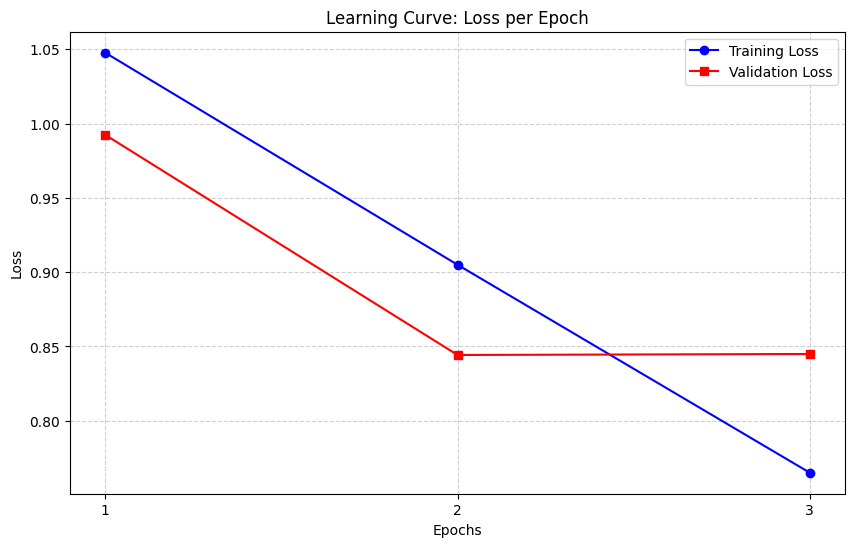

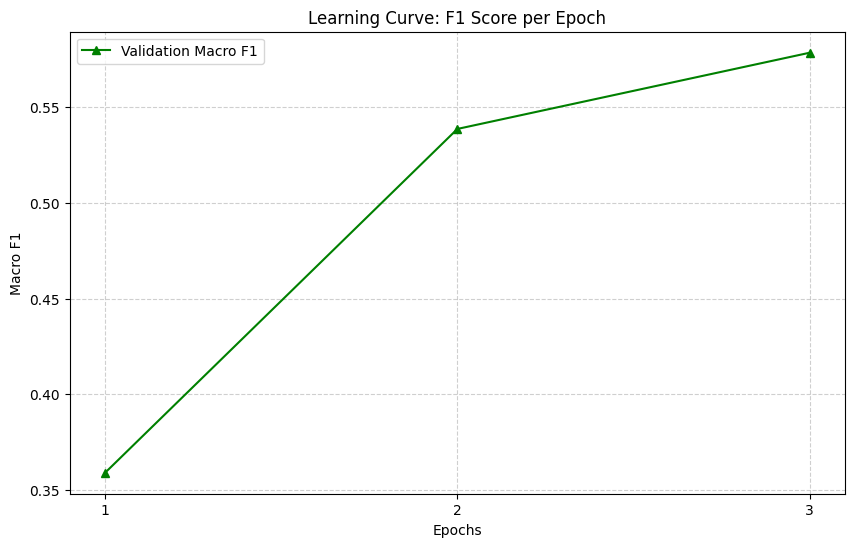

In [22]:
import matplotlib.pyplot as plt

# ΓΡΑΦΗΜΑ LEARNING CURVE (LOSS)
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(final_history['train_loss']) + 1)

plt.plot(epochs_range, final_history['train_loss'], 'b-o', label='Training Loss')
plt.plot(epochs_range, final_history['val_loss'], 'r-s', label='Validation Loss')

plt.title('Learning Curve: Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Learning_Curve:_Loss_per_Epoch.png', dpi=300, bbox_inches='tight')
plt.show()

# ΓΡΑΦΗΜΑ F1-SCORE
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, final_history['val_f1'], 'g-^', label='Validation Macro F1')
plt.title('Learning Curve: F1 Score per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Macro F1')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Learning_Curve:_F1_Score_per_Epoch.png', dpi=300, bbox_inches='tight')
plt.show()

Εξαγωγή δεδομένων από το καλύτερο μοντέλο.


Generating plots: 100%|██████████| 84/84 [00:10<00:00,  7.97it/s]


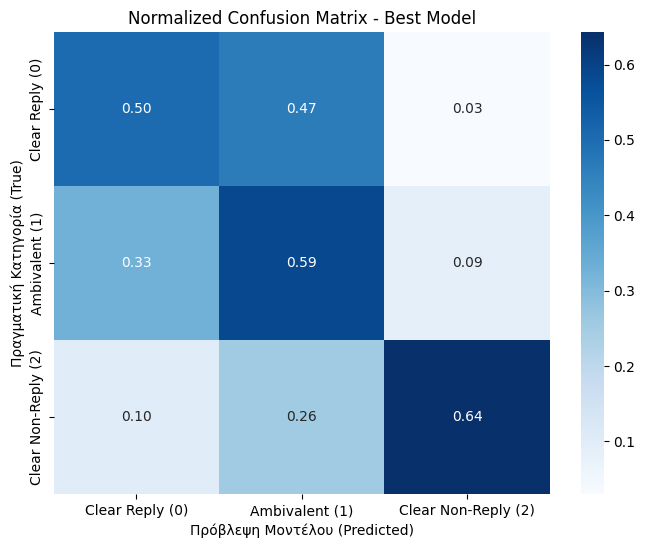

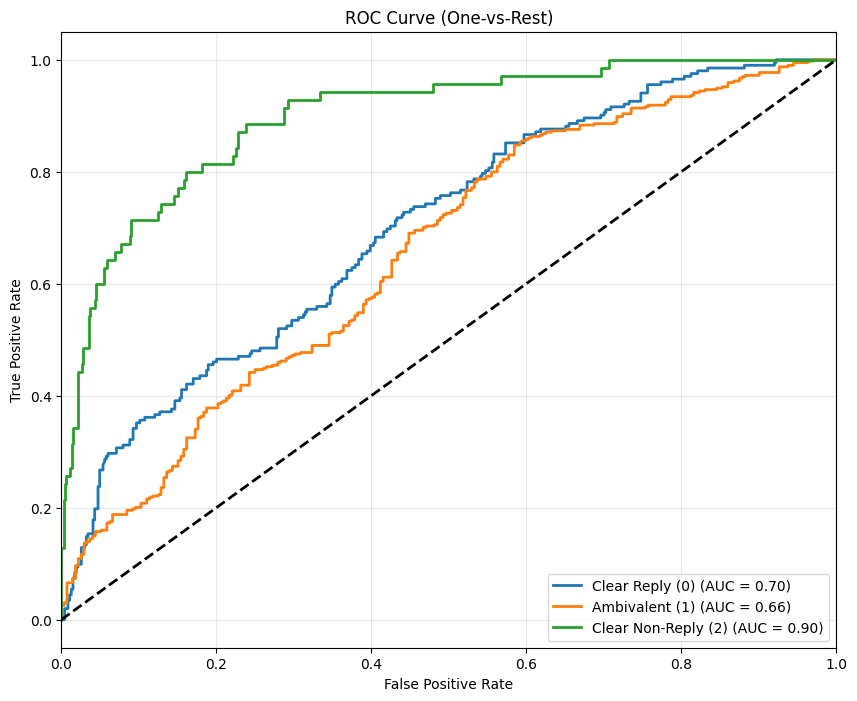

In [23]:
all_preds = []
all_labels = []
all_probs = []

print("Εξαγωγή δεδομένων από το καλύτερο μοντέλο.")
best_model.eval()
with torch.no_grad():

    for batch in tqdm(val_loader_final, desc="Generating plots"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)

        probs = F.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
target_names = ['Clear Reply (0)', 'Ambivalent (1)', 'Clear Non-Reply (2)']

# CONFUSION MATRIX
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Πραγματική Κατηγορία (True)')
plt.xlabel('Πρόβλεψη Μοντέλου (Predicted)')
plt.title('Normalized Confusion Matrix - Best Model')
plt.savefig('Normalized_Confusion_Matrix_Best_Model.png', dpi=300, bbox_inches='tight')
plt.show()

# MULTI-CLASS ROC CURVE
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{target_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig('ROC_Curve_One_vs_Rest.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
analysis_df = pd.DataFrame({
    'Question': val_df['interview_question'].values,
    'Answer': val_df['interview_answer'].values,
    'True_Label': all_labels,
    'Predicted_Label': all_preds
})

label_map = {0: 'Clear Reply', 1: 'Ambivalent', 2: 'Clear Non-Reply'}
analysis_df['True_Label_Name'] = analysis_df['True_Label'].map(label_map)
analysis_df['Predicted_Label_Name'] = analysis_df['Predicted_Label'].map(label_map)

errors_df = analysis_df[analysis_df['True_Label'] != analysis_df['Predicted_Label']]

errors_filename = 'distilbert_error_analysis.csv'
errors_df.to_csv(errors_filename, index=False)

print(f"Βρέθηκαν {len(errors_df)} λανθασμένες προβλέψεις.")
print(f"Το αρχείο {errors_filename} αποθηκεύτηκε στα Outputs.")
display(errors_df[['Question', 'Answer', 'True_Label_Name', 'Predicted_Label_Name']].head())

Βρέθηκαν 288 λανθασμένες προβλέψεις.
Το αρχείο distilbert_error_analysis.csv αποθηκεύτηκε στα Outputs.


,Question,Answer,True_Label_Name,Predicted_Label_Name
0,"Q. Thank you, Mr. President. As you well know,...","Well, no, Major, I think if you look at the hi...",Ambivalent,Clear Reply
1,"Q. Thank you, Mr. President, Prime Minister.Mr...","With respect to Kashmir, obviously, this is a ...",Clear Reply,Ambivalent
3,Q. Where is your line in the sand?,"Well, look, I've got a whole bunch of lines in...",Clear Reply,Ambivalent
7,"Q. Thank you, sir. Can you talk about your con...","Jennifer [Jennifer Loven, Associated Press], I...",Clear Reply,Ambivalent
9,Q. ——why are you pitting Americans against one...,"Excuse me. Peter. Peter, what, are you trying ...",Ambivalent,Clear Non-Reply


In [25]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/ys-19-2025-2026-assignment-2/sample_solution.csv
/kaggle/input/datasets/agapikallinikou/sample-solution-csv/sample_solution.csv


In [26]:
path_to_sample = '/kaggle/input/competitions/ys-19-2025-2026-assignment-2/sample_solution.csv'


sample_sub = pd.read_csv(path_to_sample)

test_preds = []
best_model.eval()

print("\nGenerating predictions for the Test Set.")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

id2label = {
    0: 'Clear Reply',
    1: 'Ambivalent',
    2: 'Clear Non-Reply'
}

submission_df = pd.DataFrame({
    'Id': sample_sub['Id'],
    'Predicted': test_preds
})

submission_df['Predicted'] = submission_df['Predicted'].map(id2label)

submission_df.to_csv('submission.csv', index=False)

filename_prof = 'submission_distilbert-base-uncased.csv'
submission_df.to_csv(filename_prof, index=False)

print(f"Δημιουργήθηκαν και τα δύο αρχεία ('submission.csv' & '{filename_prof}').")
print(f"Συνολικές προβλέψεις: {len(submission_df)}")
display(submission_df.head())


Generating predictions for the Test Set.


Testing: 100%|██████████| 20/20 [00:05<00:00,  3.91it/s]

Δημιουργήθηκαν και τα δύο αρχεία ('submission.csv' & 'submission_distilbert-base-uncased.csv').
Συνολικές προβλέψεις: 308


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Clear Reply
4,4,Clear Reply
